<a href="https://colab.research.google.com/github/ashutosh830/CEI_Program_Assignment/blob/main/week2_Ashutosh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (2640, 12)
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               

# DATA PREPROCESSING

In [16]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Create Date Column
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)


Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [17]:

# Feature Engineering
df["Quarter"] = df["Date"].dt.quarter

df["Production_Delivery_Ratio"] = (
    df["Production_Units"] /
    df["Estimated_Deliveries"]
)

In [18]:
# Fill any infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

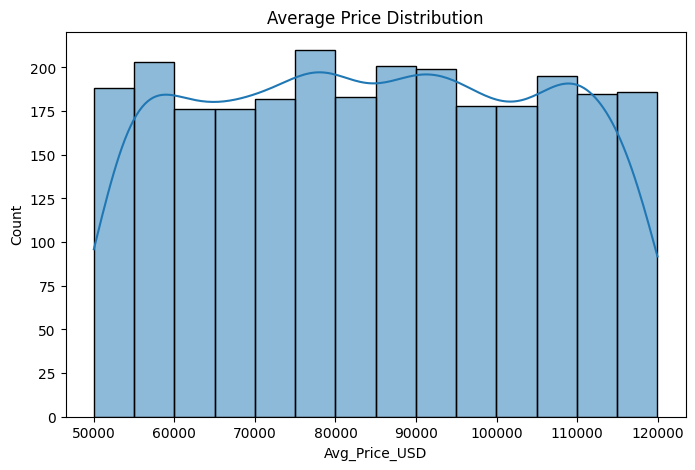

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Avg_Price_USD"], kde=True)
plt.title("Average Price Distribution")
plt.show()

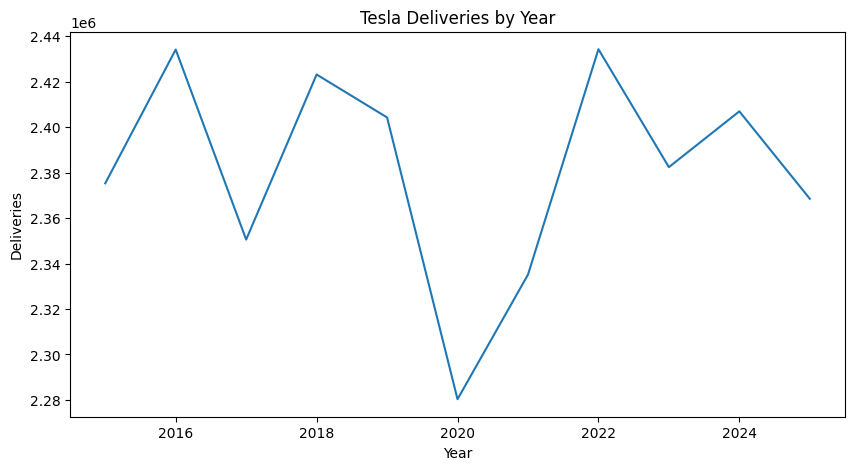

In [20]:
# Deliveries Trend
plt.figure(figsize=(10,5))
df.groupby("Year")["Estimated_Deliveries"].sum().plot()
plt.title("Tesla Deliveries by Year")
plt.ylabel("Deliveries")
plt.show()

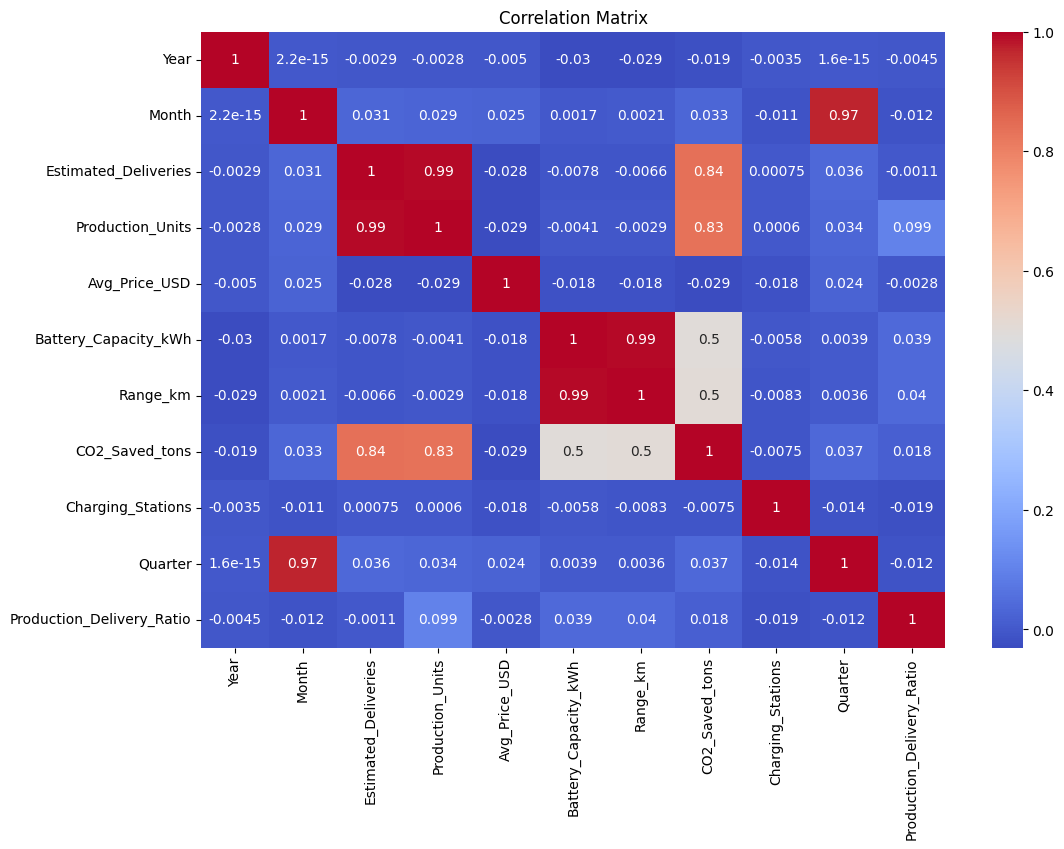

In [21]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

# ML MODELS

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [23]:
# Target
y = df["Avg_Price_USD"]

# Remove target and date
X = df.drop(
    columns=[
        "Avg_Price_USD",
        "Date"
    ]
)

In [24]:
# Numeric Columns
num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

# Categorical Columns
cat_cols = X.select_dtypes(
    include=["object"]
).columns

# Preprocessor

In [25]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Train Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# LINEAR MODEL

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_preds = lr_pipeline.predict(X_test)

print("\nLinear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2:", r2_score(y_test, lr_preds))


Linear Regression Results
MAE: 16797.974870548376
RMSE: 19500.852189310863
R2: -0.008407300957260277


# LASSO MODEL

In [28]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1,
                   max_iter=8000))
])

lasso_pipeline.fit(X_train, y_train)

lasso_preds = lasso_pipeline.predict(X_test)

print("\nLasso Regression Results")
print("MAE:", mean_absolute_error(y_test, lasso_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_preds)))
print("R2:", r2_score(y_test, lasso_preds))


Lasso Regression Results
MAE: 16797.941293590087
RMSE: 19500.599504595968
R2: -0.008381168000812567


# HYPER TUNNING FOR LASSO

In [29]:
from sklearn.model_selection import GridSearchCV

lasso_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_search = GridSearchCV(
    lasso_pipeline,
    lasso_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

print("\nBest Lasso Alpha:")
print(lasso_search.best_params_)

best_lasso = lasso_search.best_estimator_

lasso_preds = best_lasso.predict(X_test)

print("\nTuned Lasso Results")
print("MAE:", mean_absolute_error(y_test, lasso_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_preds)))
print("R2:", r2_score(y_test, lasso_preds))


Best Lasso Alpha:
{'model__alpha': 0.1}

Tuned Lasso Results
MAE: 16797.941293590087
RMSE: 19500.599504595968
R2: -0.008381168000812567


# RANDOM FOREST MODEL

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

# Predictions
preds = rf_pipeline.predict(X_test)

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)


In [31]:
print("\nRandom Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


Random Forest Results
MAE: 17108.165821401515
RMSE: 20033.170468570068
R2: -0.06421205352368364


# HYPERPARAMATER TUNNING

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

preds_best = best_model.predict(X_test)


Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [33]:
print("\nTuned Model Results")
print(
    "MAE:",
    mean_absolute_error(y_test, preds_best)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, preds_best))
)

print(
    "R2:",
    r2_score(y_test, preds_best)
)


Tuned Model Results
MAE: 17058.74542432033
RMSE: 19890.553308705716
R2: -0.04911362921940632


# FEATURE IMPORTANCE

In [34]:
feature_names = (
    num_cols.tolist() +
    list(
        best_model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(cat_cols)
    )
)

importances = (
    best_model.named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features")
print(importance_df.head(10))



Top Features
                      Feature  Importance
8   Production_Delivery_Ratio    0.163516
7           Charging_Stations    0.154733
6              CO2_Saved_tons    0.136690
5                    Range_km    0.122736
2        Estimated_Deliveries    0.079423
3            Production_Units    0.074627
0                        Year    0.065846
1                       Month    0.063851
10              Region_Europe    0.013541
12       Region_North America    0.013089


# TIME SERIES FORECASTING


Next 12 Months Forecast
2026-01-01    203819.655291
2026-02-01    202894.176208
2026-03-01    199011.662577
2026-04-01    198667.010489
2026-05-01    200971.493839
2026-06-01    201391.449843
2026-07-01    201412.663910
2026-08-01    201031.409119
2026-09-01    200601.086701
2026-10-01    200710.068214
2026-11-01    200864.721560
2026-12-01    200936.680134
Freq: MS, Name: predicted_mean, dtype: float64


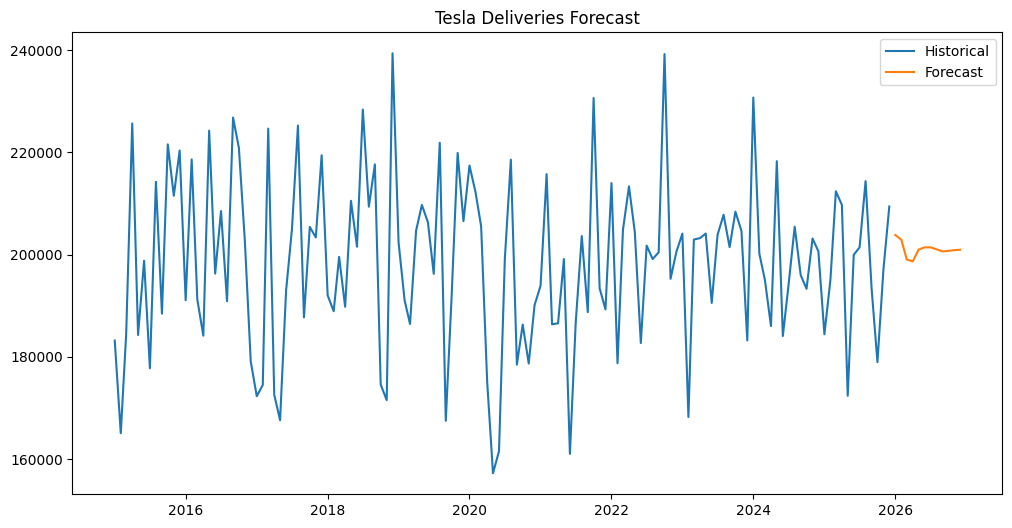

In [35]:
monthly = (
    df.groupby("Date")["Estimated_Deliveries"]
    .sum()
    .reset_index()
)

monthly = monthly.sort_values("Date")

monthly.set_index("Date", inplace=True)

from statsmodels.tsa.arima.model import ARIMA


monthly = monthly.asfreq('MS')

model = ARIMA(
    monthly["Estimated_Deliveries"],
    order=(5,1,0)
)

result = model.fit()

forecast = result.forecast(steps=12)

print("\nNext 12 Months Forecast")
print(forecast)

# Forecast Plot
plt.figure(figsize=(12,6))

plt.plot(
    monthly.index,
    monthly["Estimated_Deliveries"],
    label="Historical"
)

future_dates = pd.date_range(
    start=monthly.index.max(),
    periods=13,
    freq="MS"
)[1:]

plt.plot(
    future_dates,
    forecast,
    label="Forecast"
)

plt.legend()
plt.title("Tesla Deliveries Forecast")
plt.show()

# COMPARISON OF ALL MODELS

In [36]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Lasso",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, lasso_preds),
        mean_absolute_error(y_test, preds_best)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, lasso_preds)),
        np.sqrt(mean_squared_error(y_test, preds_best))
    ],
    "R2": [
        r2_score(y_test, lr_preds),
        r2_score(y_test, lasso_preds),
        r2_score(y_test, preds_best)
    ]
})

print(results.sort_values("R2", ascending=False))

               Model           MAE          RMSE        R2
1              Lasso  16797.941294  19500.599505 -0.008381
0  Linear Regression  16797.974871  19500.852189 -0.008407
2      Random Forest  17058.745424  19890.553309 -0.049114
